# Revenue-Optimal Dynamic Pricing using Reinforcement Learning
#### Policy Learning in a Competitive and Seasonal Synthetic Market

---

## Business Problem

Pricing is a sequential decision-making process where firms must continuously
adapt prices in response to demand elasticity, competitor actions, and seasonal
patterns.

In practice, companies often define pricing **policies** that remain stable for
a business cycle (e.g., a fiscal quarter), allowing operational deployment,
marketing alignment, and performance monitoring.

This project investigates how Reinforcement Learning (RL) can be used to learn
a dynamic pricing policy in a simulated market environment and deploy this
policy in a realistic business setting.

## Objective

The agent learns a pricing policy during a training phase through interactions
with a synthetic market simulator. The goal is to maximize cumulative revenue
generated by the chosen prices.

The optimization objective during training is:

$$
\max_{\pi} \; \mathbb{E}\left[\sum_{t=0}^{T_{train}} 
(price_t \cdot demand_t)\right]
$$

where:

- $price_t$ is the price chosen by the agent at time $t$
- $demand_t$ is the realized demand generated by the simulated market

## Deployment and Evaluation

After training, the learned pricing policy is **deployed over a business
quarter and evaluated without further learning**.

During this deployment phase:

- The **policy parameters remain fixed**
- Prices are **updated dynamically each period** according to the observed market state

Formally,

$$
price_t = \pi_\theta(state_t)
$$

where $\theta$ is fixed during the evaluation horizon.

This setup reflects real-world market operations where structural demand
dynamics evolve slowly, while operational pricing decisions are adjusted
frequently.

## Market Dynamics Modeled

The synthetic environment captures key economic drivers of retail demand:

- Nonlinear price elasticity with diminishing marginal sensitivity
- Competitive pricing reactions
- Seasonal demand shocks linked to major Brazilian retail holidays
- Stochastic demand fluctuations

This environment allows controlled experimentation with pricing strategies
before deployment in real-world scenarios.

## 1. Environment Design

To train the reinforcement learning pricing agent, we construct a structural
**synthetic market** simulator that captures key economic mechanisms observed in
real competitive retail environments.

Rather than assuming perfect knowledge of market dynamics, the simulator is
parameterized using **business-informed prior beliefs** about demand elasticity,
competitive behavior, and seasonal effects. This reflects real-world decision
contexts where firms must act under structural uncertainty.

### Parameter Uncertainty and Market Episodes

At the beginning of each training episode, a new set of market parameters is
sampled from predefined belief distributions. These parameters remain fixed
throughout the episode, representing a coherent synthetic market regime.

Across episodes, the agent experiences different plausible market structures,
allowing it to learn **robust pricing policies** that generalize beyond a single
assumed demand model.

### Demand Process

Daily demand is generated using a log-linear constant elasticity specification:

$$
D_t =
\exp\Big(
\alpha
+ S_t
- \epsilon \log(p_t)
+ \gamma \log(p^{comp}_t)
+ \eta_t
\Big)
$$

where:

- $\alpha$ represents baseline demand level  
- $\epsilon$ is own-price elasticity  
- $\gamma$ is cross-price elasticity  
- $p_t$ is the agent’s price  
- $p^{comp}_t$ is the competitor price  
- $\eta_t$ is a persistent stochastic demand component  

The exponential formulation ensures strictly positive demand while enabling
multiplicative economic effects.

### Seasonal Demand Dynamics

Seasonality is driven primarily by major retail holidays. Each holiday generates
a smooth demand spike modeled as a Gaussian temporal effect:

$$
S_t =
\sum_h
A_h \exp\left(
-\frac{(t - t_h)^2}{2\sigma_h^2}
\right)
$$

This structure captures demand anticipation before promotional periods and
gradual normalization afterward.

### Persistent Demand Regimes

Demand shocks evolve according to an autoregressive process:

$$
\eta_t = \rho \eta_{t-1} + \xi_t,
\quad \xi_t \sim \mathcal{N}(0,\sigma_\eta^2)
$$

This introduces temporal clustering in demand fluctuations and allows the agent
to learn intertemporal pricing responses.

### Competitive Pricing Dynamics

Competitor prices follow a partially reactive adjustment rule:

$$
p^{comp}_t =
p^{comp}_{t-1}
+
k (p_t - p^{comp}_{t-1})
+
\zeta_t
$$

where:

- $k$ controls the speed of competitive reaction  
- $\zeta_t$ represents stochastic pricing deviations  

This mechanism generates realistic endogenous price competition while avoiding
deterministic convergence to static equilibrium.

### Training Philosophy

The agent is trained across multiple synthetic market episodes generated from
business-informed parameter beliefs. This enables the learning of adaptive
pricing policies that remain effective under structural uncertainty.

After training, the learned pricing policy is deployed without further learning
over a fixed business horizon (e.g., one quarter), during which prices continue
to adjust dynamically according to observed market states.

In [17]:
import os
import gc
import math
import torch
import random
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from datetime import datetime
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

g = torch.Generator()
g.manual_seed(42)

In [18]:

def get_retail_holiday_spikes(start_date, end_date, s_mothers=10, s_fathers=10, s_blackfriday=15, s_xmas=20):

    years = list(range(start_date.year, end_date.year + 1))
    holidays = []

    for y in years:

        # Mother's day (2nd sunday of may)
        may = pd.date_range(f"{y}-05-01", f"{y}-05-31", freq="D")
        sundays = may[may.weekday == 6]
        mothers_day = sundays[1]

        holidays.append({
            "name": "mothers_day",
            "date": mothers_day,
            "sigma": s_mothers   # medium build-up window
        })

        # Father's day (2nd sunday of august)
        aug = pd.date_range(f"{y}-08-01", f"{y}-08-31", freq="D")
        sundays = aug[aug.weekday == 6]
        fathers_day = sundays[1]

        holidays.append({
            "name": "fathers_day",
            "date": fathers_day,
            "sigma": s_fathers
        })

        # Black friday (last friday of november)
        nov = pd.date_range(f"{y}-11-01", f"{y}-11-30", freq="D")
        fridays = nov[nov.weekday == 4]
        black_friday = fridays[-1]

        holidays.append({
            "name": "black_friday",
            "date": black_friday,
            "sigma": s_blackfriday   
        })

        # Christmas 
        holidays.append({
            "name": "christmas",
            "date": datetime(y, 12, 25),
            "sigma": s_xmas  
        })

    return holidays

def seasonality_signal(dates, holiday_spikes, amp_dict, sigma_dict, saturation_level=2.5):

    t = np.arange(len(dates))
    S = np.zeros(len(dates))

    for h in holiday_spikes:

        name = h["name"]
        center = pd.Timestamp(h["date"])
        idx = np.argmin(np.abs(dates - center))

        A = amp_dict[name]
        sigma = sigma_dict[name]
        bump = A * np.exp(-0.5 * ((t - idx) / sigma) ** 2)
        S += bump

    # saturation
    S = saturation_level * np.tanh(S / saturation_level)
    return S

def persistent_demand_shock(n_steps, rng, rho=0.45, shock_std=0.18):
    eta = np.zeros(n_steps)

    # stationary initialization
    stationary_std = shock_std / np.sqrt(1 - rho**2)
    eta[0] = rng.normal(0, stationary_std)

    for t in range(1, n_steps):
        eta[t] = rho * eta[t-1] + rng.normal(0, shock_std)

    return eta

def competitor_prices(agent_prices, p0, rng, k=0.22, noise_scale=0.035, price_floor=50.0):
    n = len(agent_prices)
    p_comp = np.zeros(n)
    p_comp[0] = p0

    for t in range(1, n):

        reaction = k * (agent_prices[t-1] - p_comp[t-1])
        noise = rng.normal(0, noise_scale * p_comp[t-1])
        p_comp[t] = p_comp[t-1] + reaction + noise

        if p_comp[t] < price_floor:
            p_comp[t] = price_floor

    return p_comp

def demand(agent_prices, competitor_prices, seasonality_signal, demand_shock, rng, 
    alpha=7.6, elasticity=1.6, cross_elasticity=0.45):
    
    log_mu = alpha + seasonality_signal - elasticity * np.log(agent_prices) + cross_elasticity * np.log(competitor_prices) + demand_shock
    mu = np.exp(log_mu)

    # Count-based demand
    demand = rng.poisson(mu)
    return demand, mu

def revenue(price, realized_demand):
    # Defaults and 'unchangeble' within the experiment
    unit_cost = 55
    fixed_cost = 5000

    return (price - unit_cost) * realized_demand - fixed_cost

season_amp_defaults = {
    "mothers_day": 0.9,
    "fathers_day": 0.8,
    "black_friday": 1.6,
    "christmas": 2.0
}

season_sigma_default = {
    "mothers_day": 6,
    "fathers_day": 6,
    "black_friday": 10,
    "christmas": 14
}

#### 1. Simulate the first quarter of data

This step generates an initial dataset based on an exploratory pricing policy designed to test different price levels and enable the estimation of preliminary market priors.

It should only be performed when no historical demand data is available.

##### 1.0 Business context: exploratory pricing phase

Brand X recently launched Product Y, but initial market performance has been disappointing. Sales volumes remained low during the first weeks, and the product operated below profitability due to high fixed operational costs and uncertain demand response.

A new Pricing Director was hired to address the situation. As a first step, an exploratory pricing strategy was implemented, deliberately testing a wide range of price levels in order to better understand market elasticity and competitive reactions. This approach began to generate early signs of improvement toward the end of the quarter, with increasing demand and occasional profitable days.

To further accelerate performance, the Pricing Director brought in a data scientist to develop a systematic, learning-based pricing policy. The objective is to move from heuristic experimentation toward an adaptive decision framework capable of optimizing profitability under market uncertainty.


In [19]:
dates = pd.date_range("2025-01-01", "2025-03-31", freq="D")
n = len(dates)

rng = np.random.default_rng(42)
agent_prices = rng.uniform(60, 140, n)

competitor_prices_val = competitor_prices(agent_prices=agent_prices, p0=102.0, rng=rng)

holiday_spikes = get_retail_holiday_spikes(dates.min(), dates.max())
seasonality = seasonality_signal(dates, holiday_spikes, season_amp_defaults, season_sigma_default)

demand_shock = persistent_demand_shock(n_steps=n, rng=rng)

realized_demand, expected_demand = demand(agent_prices=agent_prices, 
    competitor_prices=competitor_prices_val, seasonality_signal=seasonality, demand_shock=demand_shock, 
    rng=rng)

df_real = pd.DataFrame({
    "date": dates,
    "price_agent": agent_prices,
    "price_competitor": competitor_prices_val,
    "seasonality": seasonality,
    "demand_shock": demand_shock,
    "expected_demand": expected_demand,
    "realized_demand": realized_demand,
    "log_demand": np.log(realized_demand + 1e-8)
})

df_real["revenue"] = df_real.apply(lambda row: revenue(row["price_agent"], row["realized_demand"]), axis=1)

print(df_real.shape)
df_real.head()

(90, 9)


,date,price_agent,price_competitor,seasonality,demand_shock,expected_demand,realized_demand,log_demand,revenue
0,2025-01-01,121.916484,102.000000,3.352748e-09,0.032248,7.599997,6,1.791759,-4598.501097
1,2025-01-02,95.110275,108.097892,5.266210e-09,-0.006843,11.161432,8,2.079442,-4679.117799
2,2025-01-03,128.687834,106.930034,8.229618e-09,0.048369,7.235682,4,1.386294,-4705.248666
3,2025-01-04,115.789442,114.206988,1.279515e-08,0.256846,10.871174,15,2.708050,-4088.158365
4,2025-01-05,67.534188,114.161457,1.979225e-08,0.155070,23.261081,32,3.465736,-4598.905989


In [20]:

del dates
del seasonality
del agent_prices
del demand_shock
del expected_demand
del realized_demand
del competitor_prices_val

gc.collect()

0

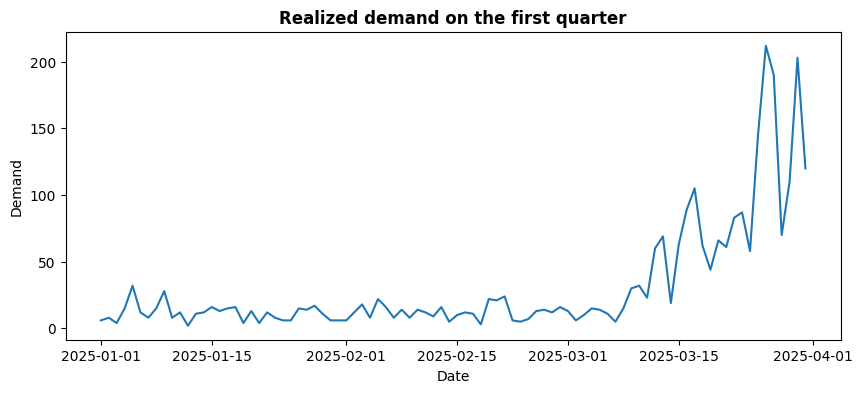

In [21]:
fig, ax = plt.subplots(figsize=(10, 4))
plt.plot(df_real['date'], df_real['realized_demand'])

ax.set_xlabel('Date')
ax.set_ylabel('Demand')
plt.title('Realized demand on the first quarter', fontweight='bold')
plt.show()

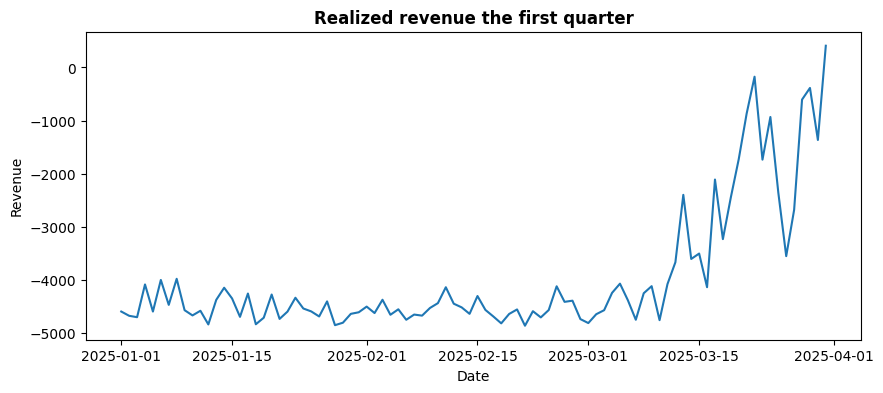

In [22]:
fig, ax = plt.subplots(figsize=(10, 4))
plt.plot(df_real['date'], df_real['revenue'])

ax.set_xlabel('Date')
ax.set_ylabel('Revenue')
plt.title('Realized revenue the first quarter', fontweight='bold')
plt.show()

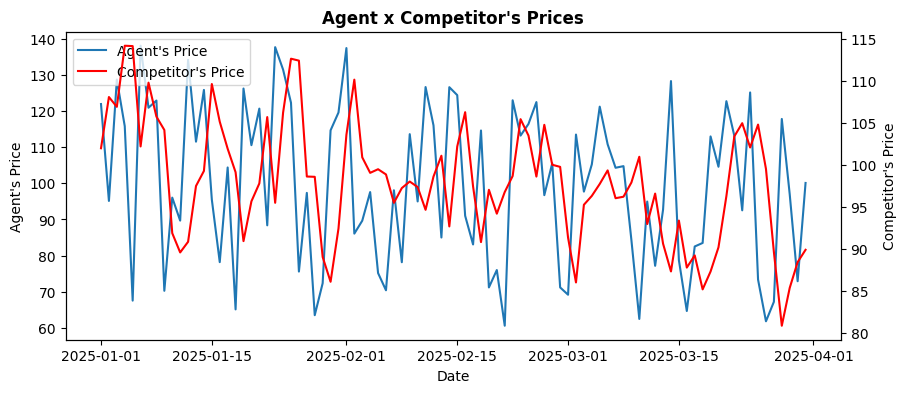

In [23]:
fig, ax = plt.subplots(figsize=(10, 4))
line1, = ax.plot(df_real['date'], df_real['price_agent'], label='Agent\'s Price')

ax2 = ax.twinx()
line2, = ax2.plot(df_real['date'], df_real['price_competitor'], color='red', label='Competitor\'s Price')

lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc="upper left")

ax.set_xlabel('Date')
ax.set_ylabel('Agent\'s Price')
ax2.set_ylabel('Competitor\'s Price')
plt.title('Agent x Competitor\'s Prices', fontweight='bold')
plt.show()

#### 2. Learning lifecycle and policy maturation strategy

The pricing system is developed through a staged learning process that reflects how real organizations progressively build decision intelligence under uncertainty.

**Phase 0: Exploratory market entry**

In the absence of reliable historical data, the company initially applies an exploratory pricing strategy designed to probe demand sensitivity and competitive reactions. This phase generates the first operational dataset, enabling the estimation of structural market parameters such as price elasticity and demand persistence. Seasonal effects are still specified using expert judgment.

**Phase 1: Simulation-based policy pre-training**

Using the estimated priors and specialist assumptions, multiple synthetic multi-year market scenarios are generated. A rule-based pricing mechanism is applied within these scenarios to produce economically reasonable pricing trajectories. The resulting simulated state–action data is then used to train an initial recurrent pricing policy offline, providing a structured starting point for deployment.

**Phase 2: Early deployment and data accumulation**

The trained pricing policy is deployed in the real market during the following quarter. New operational data is collected, allowing updated estimation of structural parameters and refinement of market beliefs.

**Phase 3: Iterative quarterly policy improvement**

At the end of each quarter, the system updates its priors using all available historical data. New synthetic scenarios are generated reflecting the updated market understanding, and the pricing policy is retrained. In later iterations, the previously deployed policy replaces the heuristic rule as the baseline decision generator, enabling progressive policy distillation and performance improvement.

**Phase 4: Seasonal model learning and long-term adaptation**
After approximately one year of observations, sufficient seasonal events have occurred to allow statistical estimation of holiday demand effects. Expert assumptions are gradually replaced by data-driven seasonal parameters. The pricing system then continues to evolve through quarterly updates, increasingly resembling an adaptive digital twin of the market environment.


#### 2.0 Phase 0

---

##### 2.0.0 Priors estimation

Structural market parameters are first statistically estimated from the observed data generated in the exploratory phase.

Parameters that cannot yet be identified from the available sample (such as seasonal demand effects) are specified using specialist assumptions, representing the prior knowledge typically provided by business experts.

Estimated parameters are represented using a **mean–variance belief structure**, allowing the model to incorporate uncertainty and probabilistic reasoning throughout the experiment.

In [24]:

def estimate_elasticities(df):

    y = np.log(df["realized_demand"].clip(lower=1))
    X = np.column_stack([
        np.ones(len(df)),
        np.log(df["price_agent"]),
        np.log(df["price_competitor"])
    ])

    beta = np.linalg.lstsq(X, y, rcond=None)[0]

    alpha_hat = beta[0]
    elasticity_hat = -beta[1]
    cross_elasticity_hat = beta[2]

    return {
        "alpha": alpha_hat,
        "elasticity": elasticity_hat,
        "cross_elasticity": cross_elasticity_hat
    }

def estimate_competitor_reaction(df):

    p_comp = df["price_competitor"].values
    p_agent = df["price_agent"].values

    dp = p_comp[1:] - p_comp[:-1]
    gap = p_agent[:-1] - p_comp[:-1]
    k_hat = np.dot(dp, gap) / np.dot(gap, gap)

    noise = dp - k_hat * gap
    noise_scale_hat = np.std(noise / p_comp[:-1])

    return {
        "k": k_hat,
        "noise_scale": noise_scale_hat
    }

def estimate_demand_regime(df, elasticity_params):

    log_d = np.log(df["realized_demand"].clip(lower=1))

    signal = (
        elasticity_params["alpha"]
        - elasticity_params["elasticity"] * np.log(df["price_agent"])
        + elasticity_params["cross_elasticity"] * np.log(df["price_competitor"])
    )

    residual = log_d - signal
    r1 = residual[:-1]
    r2 = residual[1:]

    rho_hat = np.dot(r1, r2) / np.dot(r1, r1)
    shock_std_hat = np.std(r2 - rho_hat * r1)

    return {
        "rho": rho_hat,
        "shock_std": shock_std_hat
    }

def build_priors(elasticity_params, competitor_params, regime_params, 
    uncertainty_level=0.30, floor_level=0.05):
    
    def make_prior(mean):

        base_std = abs(mean) * uncertainty_level
        floor_std = abs(mean) * floor_level
        std = max(base_std, floor_std)
        return {"mean": mean, "std": std}

    priors = {
        "alpha": make_prior(elasticity_params["alpha"]),
        "elasticity": make_prior(elasticity_params["elasticity"]),
        "cross_elasticity": make_prior(elasticity_params["cross_elasticity"]),
        "k": make_prior(competitor_params["k"]),
        "noise_scale": make_prior(competitor_params["noise_scale"]),
        "rho": make_prior(regime_params["rho"]),
        "shock_std": make_prior(regime_params["shock_std"]),
    }

    return priors

def get_uncertainty_level(base_uncertainty=0.3):

    uncertainty_level = base_uncertainty / math.sqrt(n)
    return uncertainty_level

def sample_market_parameters(priors, rng):

    params = {}

    params["alpha"] = rng.normal(priors["alpha"]["mean"], priors["alpha"]["std"])

    # elasticities must be positive
    params["elasticity"] = max(0.05, 
        rng.normal(priors["elasticity"]["mean"], priors["elasticity"]["std"]))

    params["cross_elasticity"] = max(0.01,
        rng.normal(priors["cross_elasticity"]["mean"], priors["cross_elasticity"]["std"]))

    # competitor reaction (0 < k < 1)
    params["k"] = np.clip(
        rng.normal(priors["k"]["mean"], priors["k"]["std"]),
        0.01, 0.95)

    # noise scale must be positive but not huge
    params["noise_scale"] = np.clip(
        rng.normal(priors["noise_scale"]["mean"], priors["noise_scale"]["std"]),
        0.005, 0.25)

    # persistence must be stationary
    params["rho"] = np.clip(
        rng.normal(priors["rho"]["mean"], priors["rho"]["std"]),
        0.0, 0.95)

    # demand innovation std positive
    params["shock_std"] = np.clip(
        rng.normal(priors["shock_std"]["mean"], priors["shock_std"]["std"]),
        0.02, 0.6)

    return params

def estimate_market_priors(df, uncertainty_level=0.30, floor_level=0.05):

    elasticity_params = estimate_elasticities(df)
    competitor_params = estimate_competitor_reaction(df)
    regime_params = estimate_demand_regime(df, elasticity_params)

    # build belief distributions
    priors = build_priors(elasticity_params, competitor_params, regime_params,
        uncertainty_level=uncertainty_level, floor_level=floor_level)

    return priors


In [25]:
uncertainty_level = get_uncertainty_level()
priors = estimate_market_priors(df_real, uncertainty_level=uncertainty_level)

##### 2.0.1 Expert Prior Assumptions for Seasonal Demand

Seasonal demand effects are initially specified using expert judgment rather than empirical estimation. Pricing managers typically have qualitative expectations about the relative strength of major retail events such as Christmas and Black Friday, as well as secondary promotional periods like Mother’s Day and Father’s Day.

These expert assumptions are intentionally imperfect: strong events are slightly underestimated in intensity, while mid-level events may be modestly overestimated. In addition, promotional effects are assumed to be more temporally spread than they actually are. This reflects realistic managerial uncertainty before sufficient historical data becomes available.

Such biased but plausible priors create a credible starting point for the model, allowing subsequent data-driven estimation to refine seasonal demand dynamics over time.


In [26]:
season_amp_expert_guess = {
    "mothers_day": 0.7,   
    "fathers_day": 0.9,   
    "black_friday": 1.2,  
    "christmas": 1.6      
}

season_sigma_expert_guess = {
    "mothers_day": 9,      
    "fathers_day": 8,      
    "black_friday": 14,    
    "christmas": 18        
}


#### 2.1 Phase 1

---

##### 2.1.0 Rule-based pricing function

In this section, we develop a heuristic pricing function that will be used to generate pricing trajectories in the synthetic market scenarios created during Phase 1.


In [27]:
def build_features(df):

    features = [
        "rel_price_position",
        "comp_gap_slow",
        "demand_trend_slow",
        "demand_trend_medium",
        "revenue_pressure_slow",
        "price_regime_memory",
        "price_volatility_regime"
    ]

    n = len(df)

    # ================= INITIAL BUILD =================
    if not set(features).issubset(df.columns):

        # relative long-term price positioning vs competitor anchor
        df["rel_price_position"] = (
            df["price_agent"].shift(1)
            / df["price_competitor"].shift(1).rolling(30, min_periods=1).mean()
        )

        # smooth competitive pressure removing tactical noise
        df["comp_gap_slow"] = (
            df["price_competitor"].shift(1).rolling(14, min_periods=1).mean()
            - df["price_agent"].shift(1).rolling(14, min_periods=1).mean()
        ) / df["price_agent"].shift(1)

        # structural demand cycle capturing macro consumption regime
        slow_demand = df["realized_demand"].shift(1).rolling(60, min_periods=1).mean()
        df["demand_trend_slow"] = (
            slow_demand
            / slow_demand.rolling(120, min_periods=1).mean()
            - 1
        )

        # medium demand acceleration signal for tactical stance
        df["demand_trend_medium"] = (
            df["realized_demand"].shift(1).rolling(21, min_periods=1).mean()
            / df["realized_demand"].shift(1).rolling(60, min_periods=1).mean()
            - 1
        )

        # long profitability pressure guiding margin expansion risk
        df["revenue_pressure_slow"] = np.tanh(
            df["revenue"].shift(1).rolling(45, min_periods=1).sum() / 80000
        )

        # deviation from recent equilibrium band controlling overshoot
        df["price_regime_memory"] = np.log(
            df["price_agent"].shift(1)
            / df["price_agent"].shift(1).rolling(30, min_periods=1).mean()
        )

        # short-term instability regime moderating adjustment aggressiveness
        df["price_volatility_regime"] = (
            np.log(
                df["price_agent"].shift(1)
                / df["price_agent"].shift(2)
            )
            .rolling(14, min_periods=1)
            .std()
        )

        return df, features

    # ================= INCREMENTAL UPDATE =================
    i = n - 1

    # relative competitive positioning anchor
    df.loc[i, "rel_price_position"] = (
        df.loc[i-1, "price_agent"]
        / df["price_competitor"].iloc[max(0, i-30):i].mean()
    )

    # persistent competitive mispricing pressure
    comp_mean = df["price_competitor"].iloc[max(0, i-14):i].mean()
    agent_mean = df["price_agent"].iloc[max(0, i-14):i].mean()
    df.loc[i, "comp_gap_slow"] = (
        (comp_mean - agent_mean)
        / df.loc[i-1, "price_agent"]
    )

    # slow demand regime shift
    slow_demand = df["realized_demand"].iloc[max(0, i-60):i].mean()
    slow_demand_ref = df["realized_demand"].iloc[max(0, i-120):i].mean()
    df.loc[i, "demand_trend_slow"] = (
        slow_demand / slow_demand_ref - 1
        if slow_demand_ref > 0 else 0.0
    )

    # medium demand tactical drift
    demand_21 = df["realized_demand"].iloc[max(0, i-21):i].mean()
    demand_60 = df["realized_demand"].iloc[max(0, i-60):i].mean()
    df.loc[i, "demand_trend_medium"] = (
        demand_21 / demand_60 - 1
        if demand_60 > 0 else 0.0
    )

    # profitability regime saturation signal
    rev_sum = df["revenue"].iloc[max(0, i-45):i].sum()
    df.loc[i, "revenue_pressure_slow"] = np.tanh(rev_sum / 80000)

    # price inertia / overshooting detector
    price_mean = df["price_agent"].iloc[max(0, i-30):i].mean()
    df.loc[i, "price_regime_memory"] = (
        np.log(df.loc[i-1, "price_agent"] / price_mean)
        if price_mean > 0 else 0.0
    )

    # local volatility state reducing optimal move size
    returns = np.log(
        df["price_agent"].iloc[max(1, i-14):i]
        / df["price_agent"].iloc[max(0, i-15):i-1]
    )
    df.loc[i, "price_volatility_regime"] = (
        returns.std() if len(returns) > 1 else 0.0
    )

    return df, features

In [31]:
# def build_features(df):

#     features = [
#         "demand_lag_1", "demand_ma_7",
#         "revenue_roll_7", "revenue_roll_30",
#         "price_lag_1", "competitor_price_lag_1",
#         "price_change_1", "demand_change_1",
#         "competitor_gap"
#     ]

#     n = len(df)

#     # first call or columns missing
#     if not set(features).issubset(df.columns):

#         # immediate demand reaction signal
#         # lagged observed demand used to infer price elasticity response
#         df["demand_lag_1"] = df["realized_demand"].shift(1)

#         # short-term demand trend smoothing Poisson noise
#         # rolling mean extracts underlying demand momentum signal
#         df["demand_ma_7"] = df["realized_demand"].shift(1).rolling(7, min_periods=1).mean()

#         # long-term demand trend 
#         df["demand_ma_30"] = df["realized_demand"].shift(1).rolling(30, min_periods=1).mean()

#         df["demand_ma_7_lag_3"] = df["demand_ma_7"].shift(3)

#         # short-term business performance pressure
#         # recent cumulative profit influences tactical pricing decisions
#         df["revenue_roll_7"] = df["revenue"].shift(1).rolling(7, min_periods=1).sum()

#         # medium-term performance signal guiding strategic pricing
#         # longer horizon profitability affects risk appetite and positioning
#         df["revenue_roll_30"] = df["revenue"].shift(1).rolling(30, min_periods=1).sum()

#         # last pricing decision persistence / inertia signal
#         # captures operational stickiness and managerial adjustment patterns
#         df["price_lag_1"] = df["price_agent"].shift(1)

#         # competitive positioning reference
#         # relative price level influences market share dynamics
#         df["competitor_price_lag_1"] = df["price_competitor"].shift(1)

#         # very short-term pricing momentum
#         # captures tactical managerial reactions to immediate price performance
#         df["price_change_1"] = np.log(
#             df["price_agent"].shift(1) / df["price_agent"].shift(2)
#         )

#         # very short-term demand acceleration
#         # detects sudden demand shocks that may justify aggressive pricing moves
#         df["demand_change_1"] = np.log(
#             df["realized_demand"].shift(1) / df["realized_demand"].shift(2)
#         )

#         # instantaneous competitive positioning gap
#         # measures relative attractiveness versus competitor offer
#         df["competitor_gap"] = (
#             (df["price_competitor"].shift(1) - df["price_agent"].shift(1))
#             / df["price_agent"].shift(1)
#         )

#         return df, features

#     # incremental updates (on last row)
#     i = n - 1

#     df.loc[i, "price_lag_1"] = df.loc[i-1, "price_agent"]
#     df.loc[i, "demand_lag_1"] = df.loc[i-1, "realized_demand"]
#     df.loc[i, "competitor_price_lag_1"] = df.loc[i-1, "price_competitor"]

#     df.loc[i, "revenue_roll_7"] = df["revenue"].iloc[max(0, i-7):i].sum()
#     df.loc[i, "revenue_roll_30"] = df["revenue"].iloc[max(0, i-30):i].sum()
#     df.loc[i, "demand_ma_7"] = df["realized_demand"].iloc[max(0, i-7):i].mean()
#     df.loc[i, "demand_ma_30"] = df["realized_demand"].iloc[max(0, i-30):i].mean()
#     df.loc[i, "demand_ma_7_lag_3"] = df.loc[i-3, "demand_ma_7"]

#     # tactical price momentum
#     df.loc[i, "price_change_1"] = np.log(
#         df.loc[i-1, "price_agent"] / df.loc[i-2, "price_agent"]
#     ) if i >= 2 else 0.0

#     # tactical demand momentum
#     df.loc[i, "demand_change_1"] = np.log(
#         df.loc[i-1, "realized_demand"] / df.loc[i-2, "realized_demand"]
#     ) if i >= 2 else 0.0

#     # competitive gap signal
#     df.loc[i, "competitor_gap"] = (
#         (df.loc[i-1, "price_competitor"] - df.loc[i-1, "price_agent"])
#         / df.loc[i-1, "price_agent"]
#     )

#     return df, features



def competitor_price_step(price_prev, comp_prev, rng, k, noise_scale, price_floor):

    comp = comp_prev + k * (price_prev - comp_prev) \
           + rng.normal(0, noise_scale * comp_prev)

    if comp < price_floor:
        comp = price_floor

    return comp

def simulate_scenario(df, priors, season_amp, season_sigma,
    pricing_policy_fn, rng, horizon_days=3*365, price_min=60, price_max=140):

    df_sim = df.copy().reset_index(drop=True)

    # sample structural parameters
    params = sample_market_parameters(priors, rng)

    # build calendar
    start_date = df_sim["date"].iloc[-1] + pd.Timedelta(days=1)
    dates = pd.date_range(start_date, periods=horizon_days, freq="D")

    holiday_spikes = get_retail_holiday_spikes(dates.min(), dates.max())
    seasonality = seasonality_signal(dates, holiday_spikes, season_amp, season_sigma)

    demand_shock = persistent_demand_shock(horizon_days, rng,
        rho=params["rho"], shock_std=params["shock_std"])

    for t in range(horizon_days):

        # build features using full historical + simulated path
        df_sim, features = build_features(df_sim)

        # pricing decision (callable policy)
        price = pricing_policy_fn(df_sim, price_min=price_min, price_max=price_max)
        
        # competitor reaction
        comp_prev = df_sim.iloc[-1]["price_competitor"]
        price_prev = df_sim.iloc[-1]["price_agent"]

        comp = competitor_price_step(price_prev, comp_prev, rng,
            k=params["k"], noise_scale=params["noise_scale"], price_floor=50.0)

        # demand model (single stochastic layer)
        demand_arr, mu_arr = demand(
            np.array([price]),
            np.array([comp]),
            np.array([seasonality[t]]),
            np.array([demand_shock[t]]),
            rng,
            alpha=params["alpha"],
            elasticity=params["elasticity"],
            cross_elasticity=params["cross_elasticity"]
        )

        demand_val = demand_arr[0]
        mu_val = mu_arr[0]

        # profit (reward)
        rev = revenue(price, demand_val)

        # append new row
        new_row = {
            "date": dates[t],
            "price_agent": price,
            "price_competitor": comp,
            "seasonality": seasonality[t],
            "demand_shock": demand_shock[t],
            "expected_demand": mu_val,
            "realized_demand": demand_val,
            "log_demand": np.log(demand_val + 1e-8),
            "revenue": rev
        }

        df_sim = pd.concat([df_sim, pd.DataFrame([new_row])], ignore_index=True)

    return df_sim

def rule_based_policy(df, price_min=60, price_max=140):

    row = df.iloc[-1]

    # ===== control parameters (economically calibrated) =====
    signal_strength = 0.028      # ↑ global move size
    noise_std = 0.018            # slight realism boost

    comp_weight = 0.50           # stronger competitor tracking
    demand_weight = 0.18         # more tactical demand sensitivity
    macro_demand_weight = 0.22   # preserve slow cycle

    profit_weight = 0.12         # slightly reduced strategic push
    inertia_weight = 0.16        # ↓ damping → more oscillation

    # ===== competitive anchoring drift =====
    comp_gap = row["comp_gap_slow"]
    drift = comp_weight * comp_gap

    # ===== structural demand regime =====
    drift += macro_demand_weight * row["demand_trend_slow"]

    # ===== medium tactical demand =====
    drift += demand_weight * row["demand_trend_medium"]

    # ===== profitability pressure =====
    drift += profit_weight * row["revenue_pressure_slow"]

    # ===== price inertia stabilizer (VERY important) =====
    drift -= inertia_weight * row["price_regime_memory"]

    # ===== stochastic market shocks =====
    noise = np.random.normal(0, noise_std)

    # ===== bounded diffusion step =====
    log_step = signal_strength * drift + noise
    log_step = 0.10 * np.tanh(log_step / 0.10)

    new_price = row["price_agent"] * np.exp(log_step)
    new_price = np.clip(new_price, price_min, price_max)

    return float(new_price)

Text(0.5, 0, 'Date')

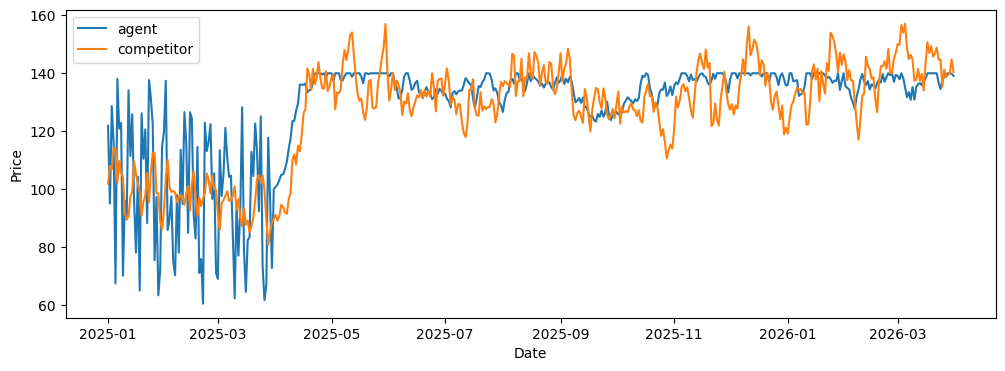

In [32]:
df_test = simulate_scenario(
    df_real,
    priors,
    season_amp_expert_guess,
    season_sigma_expert_guess,
    rule_based_policy,
    rng=np.random.default_rng(),
    horizon_days=365,
    price_min=60,
    price_max=140
)

fig, ax = plt.subplots(figsize=(12, 4))
plt.plot(df_test['date'], df_test['price_agent'], label='agent')
plt.plot(df_test['date'], df_test['price_competitor'], label='competitor')
plt.legend()
ax.set_ylabel('Price')
ax.set_xlabel('Date')

In [30]:
df_test

,date,price_agent,price_competitor,seasonality,demand_shock,expected_demand,realized_demand,log_demand,revenue,rel_price_position,comp_gap_slow,demand_trend_slow,demand_trend_medium,revenue_pressure_slow,price_regime_memory,price_volatility_regime
0,2025-01-01,121.916484,102.000000,3.352748e-09,0.032248,7.599997e+00,6,1.791759,-4.598501e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-02,95.110275,108.097892,5.266210e-09,-0.006843,1.116143e+01,8,2.079442,-4.679118e+03,1.195260,-0.163362,0.000000,0.000000,-0.057418,0.000000,NaN
2,2025-01-03,128.687834,106.930034,8.229618e-09,0.048369,7.235682e+00,4,1.386294,-4.705249e+03,0.905390,-0.036425,0.076923,0.000000,-0.115453,-0.131836,NaN
3,2025-01-04,115.789442,114.206988,1.279515e-08,0.256846,1.087117e+01,15,2.708050,-4.088158e+03,1.217759,-0.074306,-0.052632,0.000000,-0.173027,0.110388,0.389370
4,2025-01-05,67.534188,114.161457,1.979225e-08,0.155070,2.326108e+01,32,3.465736,-4.598906e+03,1.074027,-0.065354,0.211009,0.000000,-0.222123,0.003577,0.285778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450,2026-03-27,138.673795,144.033253,2.324381e+00,-0.088389,1.189997e+08,118986516,18.594521,9.956048e+09,0.981370,0.041727,-0.083040,1.094790,1.000000,0.005871,0.000000
451,2026-03-28,140.000000,146.240343,2.338743e+00,-0.157623,1.101306e+08,110133465,18.517204,9.361340e+09,0.989520,0.040839,-0.055361,1.104300,1.000000,0.019290,0.000000
452,2026-03-29,140.000000,141.390403,2.348607e+00,-0.092975,1.186101e+08,118622022,18.591453,1.008287e+10,0.994078,0.037457,-0.029237,1.106592,1.000000,0.028395,0.000000
453,2026-03-30,140.000000,146.546232,2.354365e+00,0.127579,1.487865e+08,148783518,18.818003,1.264659e+10,0.989497,0.034466,-0.002448,1.106355,1.000000,0.028059,0.000000


In [ ]:
file_path = "../data/2_rl_2025_2.csv"

if os.path.exists(file_path):

    print("Loading existing RL dataset...")
    df_all = pd.read_csv(file_path, parse_dates=["date"])

else:

    print("Dataset not found. Generating synthetic scenarios...")
    base_seed = 42

    scenarios = [
        simulate_scenario(
            df_real,
            priors,
            season_amp_expert_guess,
            season_sigma_expert_guess,
            rule_based_policy,
            rng=np.random.default_rng(base_seed + i),
            horizon_days=3 * 365,
            price_min=60,
            price_max=140
        )
        
        for i in range(200)
    ]

    dfs = []

    for i, df in enumerate(scenarios):

        tmp = df.copy()
        tmp["scenario_id"] = i

        if i == 0:
            dfs.append(tmp)
        else:
            dfs.append(tmp.iloc[len(df_real):].reset_index(drop=True))
    
    df_all = pd.concat(dfs, ignore_index=True)

    # ensure folder exists
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    df_all.to_csv(file_path, index=False)

    print("Synthetic dataset generated and saved.")

df_all = df_all.dropna().reset_index(drop=True)
print(df_all.shape)
df_all.head()

In the first learning stage, the neural network is intentionally trained to **imitate the behavior of the rule-based pricing policy**. This step is not meant to produce a final optimal strategy, but rather to provide the model with a **strong and economically consistent initial understanding of how prices should react to market signals**, such as demand momentum, competitive positioning, and recent profitability. By learning from a structured heuristic that reflects realistic managerial decision patterns, the model starts from a stable and interpretable policy prior. In later phases, reinforcement learning will be used to **refine and potentially improve this initial policy**, allowing the agent to adapt to stochastic market dynamics, uncover limitations in the heuristic, and optimize long-term revenue performance.

In [ ]:
def build_rnn_windows(df, features, target_col, window=90):

    X_list = []
    y_list = []
    
    for sid, g in df.groupby("scenario_id"):

        g = g.sort_values("date").reset_index(drop=True)
        yg = g[target_col].values
        Xg = g[features].values
        
        n = len(g)

        for t in range(window, n):
            X_list.append(Xg[t-window:t])
            y_list.append(yg[t])

    X = np.array(X_list)
    y = np.array(y_list)
    return X, y

# ensure it have all columns
# df_all, features = build_features(df_all)
features = [
    "demand_lag_1", "demand_ma_7",
    "revenue_roll_7", "revenue_roll_30",
    "price_lag_1", "competitor_price_lag_1",
    "price_change_1", "demand_change_1",
    "competitor_gap"
]

#df_all["target_phase_1"] = (df_all["price_agent"] / df_all["price_lag_1"] - 1)
df_all["target_phase_1"] = np.log(df_all["price_agent"] / df_all["price_lag_1"])
df_all = df_all.dropna().reset_index(drop=True)

rng = np.random.default_rng(42)
scenario_ids = df_all["scenario_id"].unique()
rng.shuffle(scenario_ids)

split = int(0.8 * len(scenario_ids))
train_ids = scenario_ids[:split]
test_ids = scenario_ids[split:]

df_train = df_all[df_all["scenario_id"].isin(train_ids)].copy()
df_test  = df_all[df_all["scenario_id"].isin(test_ids)].copy()

scaler_features = StandardScaler()
scaler_features.fit(df_train[features])

scaler_target = StandardScaler()
scaler_target.fit(df_train[["target_phase_1"]])

df_train[features] = scaler_features.transform(df_train[features])
df_test[features]  = scaler_features.transform(df_test[features])

df_train["norm_target_1"] = scaler_target.transform(df_train[["target_phase_1"]])
df_test["norm_target_1"]  = scaler_target.transform(df_test[["target_phase_1"]])

x_train, y_train = build_rnn_windows(df_train, features, "target_phase_1")
x_test, y_test = build_rnn_windows(df_test, features, "target_phase_1")


In [ ]:
from scipy.stats import kurtosis

fig, ax = plt.subplots(figsize=(8, 4))
df_train['target_phase_1'].hist(bins=100)
ax.set_ylabel('Num. Samples')
ax.set_xlabel('Target')
plt.legend()

plt.title('Train | Target: log(pt / pt-1)', fontweight='bold')
plt.show()

k = kurtosis(df_train['target_phase_1'], fisher=False)
print('Mean:', df_train['target_phase_1'].mean().round(8))
print('Std:', df_train['target_phase_1'].std().round(4))
print('kurtosis:', k.round(4))

In [ ]:
from scipy.stats import kurtosis

fig, ax = plt.subplots(figsize=(8, 4))
df_train['norm_target_1'].hist(bins=100)
ax.set_ylabel('Num. Samples')
ax.set_xlabel('Target')
plt.legend()

plt.title('Train | Norm. Target', fontweight='bold')
plt.show()

k = kurtosis(df_train['norm_target_1'], fisher=False)
print('Mean:', df_train['norm_target_1'].mean().round(8))
print('Std:', df_train['norm_target_1'].std().round(4))
print('kurtosis:', k.round(4))

In [ ]:

batch_size = 128 

x_train_t = torch.from_numpy(x_train).float()
y_train_t = torch.from_numpy(y_train.astype(np.float32)).unsqueeze(1)

x_val_t = torch.from_numpy(x_test).float()
y_val_t = torch.from_numpy(y_test.astype(np.float32)).unsqueeze(1)

train_loader = DataLoader(
    TensorDataset(x_train_t, y_train_t),
    batch_size=batch_size,
    shuffle=True,
    generator=g
)

val_loader = DataLoader(
    TensorDataset(x_val_t, y_val_t),
    batch_size=batch_size,
    shuffle=False,
    generator=g
)

##### 2.1.1 RNN Model Definition

In this stage, we define a Recurrent Neural Network (RNN) architecture to learn the **dynamic pricing adjustment policy** from simulated decision trajectories. The model receives sequential observations of market state variables over a **90-day rolling window**, reflecting the typical temporal horizon over which pricing strategies remain structurally stable within a business quarter.

A Gated Recurrent Unit (GRU) backbone is adopted due to its ability to efficiently capture medium to long-term temporal dependencies while maintaining a relatively low parameter count and stable training dynamics. To enhance the model’s capability to identify **strategically relevant moments in the past**, a temporal attention mechanism is applied over the sequence of hidden states. This allows the network to learn which historical periods — such as seasonal demand build-ups or shifts in competitive pressure — should exert greater influence on the current pricing decision.

The network outputs a **bounded multiplicative price adjustment**, rather than an absolute price level. This design choice improves statistical stationarity, facilitates generalization across different price regimes, and ensures a smooth transition to later reinforcement learning phases, where the same architecture will be reused as the policy network.

In [ ]:

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

class PricingRNNAttention(nn.Module):

    def __init__(self, n_features, hidden_size=64, n_layers=1, dropout=0.0,
        max_daily_adjustment=0.10):

        super().__init__()
        self.max_daily_adjustment = max_daily_adjustment

        self.rnn = nn.GRU(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )

        # temporal attention scoring
        self.attn = nn.Linear(hidden_size, 1)

        head_dim = max(8, hidden_size // 2)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, head_dim),
            nn.ReLU(),
            nn.Linear(head_dim, 1)
            #, nn.Tanh()
        )

    def forward(self, x):

        h_seq, _ = self.rnn(x)

        # attention weights
        attn_scores = self.attn(h_seq)           
        attn_weights = F.softmax(attn_scores, dim=1)

        # context vector
        context = torch.sum(attn_weights * h_seq, dim=1)
        raw_action = self.head(context)

        return raw_action.squeeze(-1), attn_weights.squeeze(-1)

In [ ]:
epsilon = 0.01

bce_loss = nn.BCELoss()
l1_loss = nn.SmoothL1Loss(reduction="none")

def pricing_loss(prob_pred, mag_pred, y_true):

    # event label
    event = (torch.abs(y_true) > epsilon).float()

    # decision loss
    loss_event = bce_loss(prob_pred, event)

    # magnitude loss (masked)
    loss_mag_all = l1_loss(mag_pred, y_true)
    loss_mag = (loss_mag_all * event).sum() / (event.sum() + 1.0)

    # combined loss
    loss = loss_event + 5.0 * loss_mag

    return loss, loss_event.detach(), loss_mag.detach()

In [ ]:
model_path = "../models/2_rl_phase_1.pt"
os.makedirs("../models", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PricingRNNAttention(n_features=len(features), hidden_size=64).to(device)

if os.path.exists(model_path):

    print("Loading existing Phase-1 RNN model...")
    model.load_state_dict(torch.load(model_path, map_location=device))

else:

    print("Training Phase-1 RNN model...")

    criterion = nn.SmoothL1Loss()
    optimizer = optim.Adam(model.parameters(), lr=3e-3)

    n_epochs = 10
    patience = 5

    best_val_loss = float("inf")
    epochs_no_improve = 0

    train_losses = []
    val_losses = []


    for epoch in range(n_epochs):

        # train
        model.train()
        running_loss = 0.0

        for xb, yb in train_loader:

            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            preds, _ = model(xb)
            preds = preds.unsqueeze(1)

            loss = criterion(preds, yb)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # validation
        model.eval()
        running_loss = 0.0

        with torch.no_grad():
            for xb, yb in val_loader:

                xb = xb.to(device)
                yb = yb.to(device)

                preds, _ = model(xb)
                preds = preds.unsqueeze(1)

                loss = criterion(preds, yb)

                running_loss += loss.item() * xb.size(0)

        epoch_val_loss = running_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        print(f"Epoch {epoch+1:02d} | Train {epoch_train_loss:.8f} | Val {epoch_val_loss:.8f}")
        
        # warly stoping
        if epoch_val_loss < best_val_loss:

            best_val_loss = epoch_val_loss
            epochs_no_improve = 0

            torch.save(model.state_dict(), model_path)
            
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print("Early stopping triggered")
            break

    print("Training finished. Loading best model.")
    model.load_state_dict(torch.load(model_path, map_location=device))

In [ ]:
def rnn_policy(df, price_min=60, price_max=140):
    
    # get last window
    window = 90
    df_window = df.iloc[-window:]
    df_window = df_window.fillna(0)

    X = df_window[features].values
    X = pd.DataFrame(X, columns=features)
    X = scaler_features.transform(X)
    X_t = torch.from_numpy(X).float().unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        adj, w = model(X_t)

    adj = adj.cpu().numpy()[0,]

    # symmetric bounded move
    log_step = 0.12 * np.tanh(adj) 
    price_ratio = np.exp(log_step)
    new_price = df.iloc[-1]["price_agent"] * price_ratio

    #price_ratio = 1 + 0.3 * (np.exp(adj) - 1)
    print(adj)

    new_price = df.iloc[-1]["price_agent"] * adj 
    new_price = np.clip(new_price, price_min, price_max)

    return float(new_price)

In [ ]:
df_new = simulate_scenario(
    df_real,
    priors,
    season_amp_expert_guess,
    season_sigma_expert_guess,
    rnn_policy,
    rng=np.random.default_rng(42),
    horizon_days=365,
    price_min=60,
    price_max=140
)

df_new.tail()

In [ ]:
last_date = df_real.iloc[-1]['date']
fig, ax = plt.subplots(figsize=(12, 4))

plt.plot(df_new['date'], df_new['revenue'])
plt.vlines(last_date, df_new['revenue'].min(), df_new['revenue'].max(), 
    linestyles="dashed", color="black")

plt.title("Revenue Simulation over Phase 1 Pricing Strategy", fontweight="bold")
ax.set_ylabel("Revenue ($)")
ax.set_xlabel("Date")


In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
line1, = ax.plot(df_new['date'], df_new['price_agent'], label='Agent\'s Price')

# ax.vlines(last_date, df_new['revenue'].min(), df_new['revenue'].max(), 
#     linestyles="dashed", color="black")

ax2 = ax.twinx()
line2, = ax2.plot(df_new['date'], df_new['price_competitor'], color='red', label='Competitor\'s Price')

lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc="upper left")

ax.set_xlabel('Date')
ax.set_ylabel('Agent\'s Price')
ax2.set_ylabel('Competitor\'s Price')
plt.title('Agent x Competitor\'s Prices', fontweight='bold')
plt.show()

In [ ]:
df_new['price_agent'].tail()